In [48]:
# Import packages.
import torch
from torch import nn
import math
import matplotlib.pyplot as plt

In [49]:
torch.manual_seed(42)

In [50]:
# Recreating sine wave from tutorial
train_data_length = 1024
train_data = torch.zeros((train_data_length, 2))

train_data[:, 0] = 2.0 * math.pi * torch.rand(train_data_length)
train_data[:, 1] = torch.sin(train_data[:, 0])

train_labels = torch.zeros(train_data_length)
train_set = [(train_data[i], train_labels[i]) for i in range(train_data_length)]

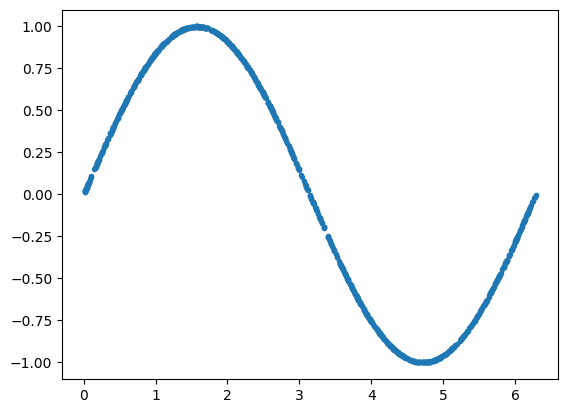

In [51]:
# Plot the training data
plt.plot(train_data[:, 0], train_data[:, 1], ".")
plt.show()

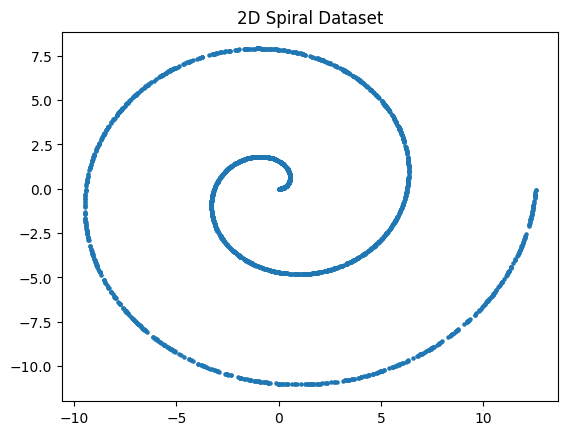

In [81]:
# 2D spiral
train_data_length = 2048 # increased length to avoid missing data
# angle (theta)
theta = 4 * math.pi * torch.rand(train_data_length)  #changge 10 to increase or decrease the number of spirals along with data length

# radius grows with theta
r = theta

# convert to Cartesian
x = r * torch.cos(theta)
y = r * torch.sin(theta)

train_data = torch.zeros((train_data_length, 2))
train_data[:, 0] = x
train_data[:, 1] = y

# Normalise to [-1, 1]
data_min = train_data.min(dim=0).values
data_max = train_data.max(dim=0).values
train_data_norm = 2 * (train_data - data_min) / (data_max - data_min) - 1

train_labels = torch.zeros(train_data_length)
train_set = [(train_data[i], train_labels[i]) for i in range(train_data_length)]

# Plot
plt.scatter(train_data[:, 0], train_data[:, 1], s=5)
plt.title("2D Spiral Dataset")
plt.show()

In [82]:
batch_size = 32
train_loader = torch.utils.data.DataLoader(
    train_set, batch_size=batch_size, shuffle=True
)

In [83]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(2, 256),
            nn.LeakyReLU(0.2), # switching activation to leakyrelu prevent dead neurons
            nn.Dropout(0.3),
            nn.Linear(256, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 1),
        )

    # Describe how the forward pass is calculated.
    def forward(self, x):
        return self.model(x)
        
# instantiate a discriminator object
discriminator = Discriminator()

In [84]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(16, 128),          # larger latent dim
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(128),         # BatchNorm stabilises training
            nn.Linear(128, 256),
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(256),
            nn.Linear(256, 256),
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(256),
            nn.Linear(256, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 2),
        )

    def forward(self, x):
        output = self.model(x)
        return output


# Instantiate generator object.
generator = Generator()

In [85]:
optimizer_discriminator = torch.optim.Adam(discriminator.parameters(), lr=0.0001, betas=(0.5, 0.999))
optimizer_generator = torch.optim.Adam(generator.parameters(), lr=0.0003, betas=(0.5, 0.999))

In [86]:
num_epochs = 3000
loss_function = nn.BCEWithLogitsLoss()
latent_dim = 16

for epoch in range(num_epochs):
    for n, (real_samples, _) in enumerate(train_loader):
        current_batch_size = real_samples.size(0)

        real_samples_labels = torch.ones((current_batch_size, 1)) * 0.9   # label smoothing
        generated_samples_labels = torch.zeros((current_batch_size, 1))

        # ── Train Discriminator ────────────────────────────────────────────────
        latent_space_samples = torch.randn((current_batch_size, latent_dim))
        generated_samples = generator(latent_space_samples)

        all_samples = torch.cat((real_samples, generated_samples.detach()))
        all_samples_labels = torch.cat((real_samples_labels, generated_samples_labels))

        discriminator.zero_grad()
        output_discriminator = discriminator(all_samples)
        loss_discriminator = loss_function(output_discriminator, all_samples_labels)
        loss_discriminator.backward()
        optimizer_discriminator.step()

        # ── Train Generator (3x per discriminator step) ────────────────────────
        for _ in range(3):
            latent_space_samples = torch.randn((current_batch_size, latent_dim))
            generator.zero_grad()
            generated_samples = generator(latent_space_samples)
            output = discriminator(generated_samples)
            loss_generator = loss_function(output, real_samples_labels)
            loss_generator.backward()
            optimizer_generator.step()

    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Loss D: {loss_discriminator:.4f} | Loss G: {loss_generator:.4f}")

Epoch: 0 | Loss D: 0.7008 | Loss G: 0.7966
Epoch: 100 | Loss D: 0.6876 | Loss G: 0.7727
Epoch: 200 | Loss D: 0.6981 | Loss G: 0.7579
Epoch: 300 | Loss D: 0.6819 | Loss G: 0.7832
Epoch: 400 | Loss D: 0.6933 | Loss G: 0.7759
Epoch: 500 | Loss D: 0.6842 | Loss G: 0.7813
Epoch: 600 | Loss D: 0.6941 | Loss G: 0.7881
Epoch: 700 | Loss D: 0.6916 | Loss G: 0.7899
Epoch: 800 | Loss D: 0.6868 | Loss G: 0.7797
Epoch: 900 | Loss D: 0.6936 | Loss G: 0.7804
Epoch: 1000 | Loss D: 0.6951 | Loss G: 0.7736
Epoch: 1100 | Loss D: 0.6929 | Loss G: 0.7861
Epoch: 1200 | Loss D: 0.6881 | Loss G: 0.7830
Epoch: 1300 | Loss D: 0.6915 | Loss G: 0.7816
Epoch: 1400 | Loss D: 0.6847 | Loss G: 0.7734
Epoch: 1500 | Loss D: 0.6859 | Loss G: 0.7644
Epoch: 1600 | Loss D: 0.6927 | Loss G: 0.7841
Epoch: 1700 | Loss D: 0.6910 | Loss G: 0.7846
Epoch: 1800 | Loss D: 0.6885 | Loss G: 0.7775
Epoch: 1900 | Loss D: 0.6910 | Loss G: 0.7833
Epoch: 2000 | Loss D: 0.6893 | Loss G: 0.7825
Epoch: 2100 | Loss D: 0.6884 | Loss G: 0.7730


In [87]:
# Generate 1000 random 2D points and feed them to the generator.
latent_space_samples = torch.randn(1000, latent_dim)
generated_samples = generator(latent_space_samples)

# Turn the PyTorch tensor into a NumPy array.
generated_samples_numpy = generated_samples.detach().numpy()

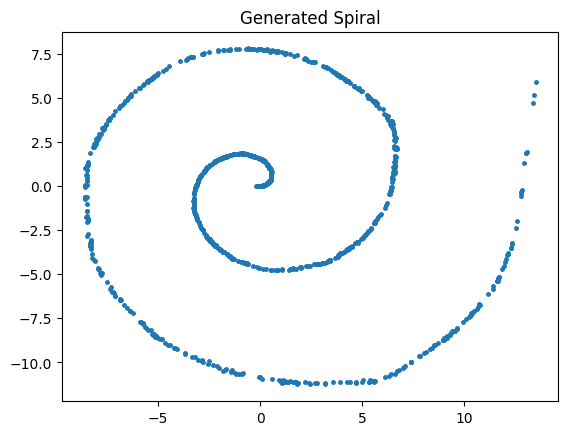

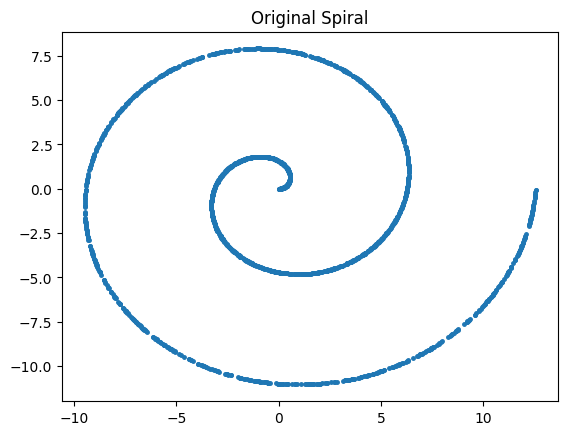

In [88]:
plt.figure()
plt.plot(generated_samples_numpy[:, 0], generated_samples_numpy[:, 1], ".", markersize=5)
plt.title("Generated Spiral")
plt.show()

# Plot 2: Original training data
plt.figure()
plt.plot(train_data[:, 0], train_data[:, 1], ".", markersize=5)
plt.title("Original Spiral")
plt.show()